# 02 · Difference-in-differences

**Question:** does subtracting a control group's change remove the seasonal bias, and how reliable is DiD when only one state is treated?

**Answer:** DiD removes most of the shared trend (Texas error **−3.4% → −0.7%**) and recovers **9.2%** of an injected 10% lift. But a placebo test across all states shows a typical single-state error of **5.1%**; pooling 6 states cuts it to **1.8%**.

$$\text{DiD lift} = \frac{T_{after} / T_{before}}{C_{after} / C_{before}} - 1$$

T = treated states, C = all other states combined.

**Data:** GA4 Google Merchandise Store public sample (BigQuery `ga4_obfuscated_sample_ecommerce`), aggregated to sessions per US state per day, 2020-11-01 to 2021-01-31. Lifts are **injected** into real data (semi-synthetic), so the true effect is always known.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/ga4_state_daily.csv", parse_dates=["date"])
START = pd.Timestamp("2021-01-04")
WINDOW = pd.Timedelta(days=28)

df_before = df[(df.date >= START - WINDOW) & (df.date < START)]
df_after  = df[(df.date >= START) & (df.date < START + WINDOW)]

## Step 1 · DiD for Texas (true effect = 0)

In [2]:
T_before = df_before[df_before.state == "Texas"].sessions.sum()
T_after  = df_after[df_after.state == "Texas"].sessions.sum()
C_before = df_before[df_before.state != "Texas"].sessions.sum()
C_after  = df_after[df_after.state != "Texas"].sessions.sum()

naive   = T_after / T_before - 1
control = C_after / C_before - 1
did     = (1 + naive) / (1 + control) - 1
print(f"Naive: {naive:.1%} | Control change: {control:.1%} | DiD: {did:.1%}")

Naive: -3.4% | Control change: -2.7% | DiD: -0.7%


## Step 2 · Inject a known +10% lift into Texas

In [3]:
df_lift = df.copy()
df_lift["sessions"] = df_lift["sessions"].astype(float)
mask = (df_lift.state == "Texas") & (df_lift.date >= START) & (df_lift.date < START + WINDOW)
df_lift.loc[mask, "sessions"] *= 1.10

df_before_lift = df_lift[(df_lift.date >= START - WINDOW) & (df_lift.date < START)]
df_after_lift  = df_lift[(df_lift.date >= START) & (df_lift.date < START + WINDOW)]

T_before_lift = df_before_lift[df_before_lift.state == "Texas"].sessions.sum()
T_after_lift  = df_after_lift[df_after_lift.state == "Texas"].sessions.sum()
C_before_lift = df_before_lift[df_before_lift.state != "Texas"].sessions.sum()
C_after_lift  = df_after_lift[df_after_lift.state != "Texas"].sessions.sum()

naive_lift   = T_after_lift / T_before_lift - 1
control_lift = C_after_lift / C_before_lift - 1
did_lift     = (1 + naive_lift) / (1 + control_lift) - 1
print(f"Naive: {naive_lift:.1%} | Control change: {control_lift:.1%} | DiD: {did_lift:.1%}")


Naive: 6.2% | Control change: -2.7% | DiD: 9.2%


## Step 3 · Reusable `did_lift(data, treated)` for any list of states

In [4]:
def did_lift(data, treated):
    before = data[(data.date >= START - WINDOW) & (data.date < START)]
    after  = data[(data.date >= START) & (data.date < START + WINDOW)]
    T_before = before[before.state.isin(treated)].sessions.sum()
    T_after  = after[after.state.isin(treated)].sessions.sum()
    C_before = before[~before.state.isin(treated)].sessions.sum()
    C_after  = after[~after.state.isin(treated)].sessions.sum()
    did  = (T_after/T_before)/(C_after/C_before) - 1
    return did

# Checks: Texas (no lift), Texas (+10%), three states
print(f"{did_lift(df, ['Texas']):.1%}")
print(f"{did_lift(df_lift, ['Texas']):.1%}")
print(f"{did_lift(df, ['Texas', 'Florida', 'Ohio']):.1%}")

-0.7%
9.2%
0.7%


## Step 4 · Parallel trends check

DiD assumes treated and control would move in parallel without the campaign. Both series are indexed to their November average.

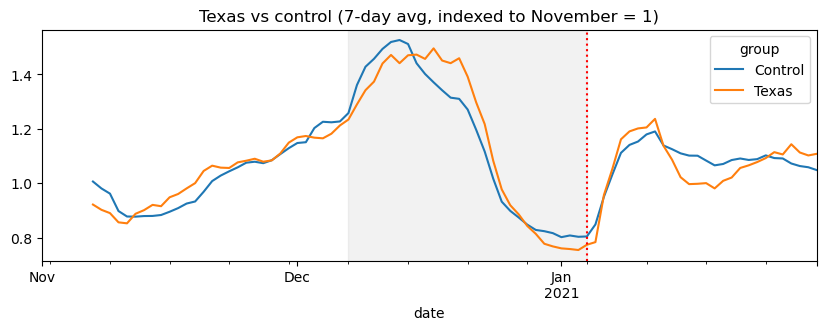

In [5]:
daily = df.assign(group=df.state.eq("Texas").map({True: "Texas", False: "Control"}))
daily = daily.groupby(["date", "group"]).sessions.sum().unstack()
indexed = daily / daily[daily.index < "2020-12-01"].mean()

ax = indexed.rolling(7).mean().plot(figsize=(10, 3), title="Texas vs control (7-day avg, indexed to November = 1)")
ax.axvline(START, color="red", ls=":")
ax.axvspan(START - WINDOW, START, alpha=0.1, color="gray")
plt.show()

## Step 5 · Placebo test: every state as the fake treated state

With a true effect of 0 everywhere, each DiD result **is** the method's error for that state.

In [6]:
# Placebo test: run DiD with EVERY state as the fake "treated" state (true effect = 0)
results = pd.DataFrame({
    "did":  {s: did_lift(df, [s]) for s in df.state.unique()},
    "size": df[df.date < START].groupby("state").sessions.mean(),
})
results["abs_error"] = results.did.abs()
results.sort_values("size", ascending=False).head(10)

,did,size,abs_error
California,-0.022100,362.062500,0.022100
Texas,-0.007228,127.156250,0.007228
New York,0.033192,116.125000,0.033192
Virginia,0.000261,112.250000,0.000261
Florida,0.045939,78.968750,0.045939
Massachusetts,0.024562,67.671875,0.024562
Illinois,0.050662,64.906250,0.050662
Pennsylvania,0.056495,52.562500,0.056495
New Jersey,0.039417,50.875000,0.039417
Washington,0.065419,50.000000,0.065419


In [7]:
results["size_group"] = pd.qcut(results["size"], 3, labels=["small", "mid", "large"])
results.groupby("size_group", observed=True).abs_error.median()

size_group
small    0.113448
mid      0.038472
large    0.024562
Name: abs_error, dtype: float64

## Step 6 · Pooling: treat several random states together

In [8]:
import numpy as np
rng = np.random.default_rng(0)

# only use states with enough traffic (median >= 10 sessions/day)
daily_median = df.groupby("state").sessions.median()
states = daily_median[daily_median >= 10].index

for n in [1, 3, 6, 10]:
    errors = [did_lift(df, list(rng.choice(states, n, replace=False))) for _ in range(200)]
    print(f"{n:>2} states pooled → typical error (std): {np.std(errors):.1%}")

 1 states pooled → typical error (std): 4.4%
 3 states pooled → typical error (std): 2.4%
 6 states pooled → typical error (std): 1.8%
10 states pooled → typical error (std): 1.6%


## Findings

| Test | Naive | DiD | Truth |
|---|---|---|---|
| Texas, no lift | −3.4% | **−0.7%** | 0% |
| Texas, +10% injected | +6.2% | **+9.2%** | 10% |

- **DiD removes the shared seasonal drop.** The remaining gap equals the no-lift error (10% − 0.7% ≈ 9.2%).
- **Parallel trends mostly hold** (daily correlation ≈ 0.92). The biggest divergence is around Dec 19, when Texas's holiday peak lasted longer; it sits inside the before window and explains part of the −0.7%.
- **Texas was a lucky draw.** Across all states the median placebo error is **5.1%**; Illinois shows **+5.1%** and Washington **+6.5%** "lift" with zero ads.

| State size (tercile) | Median placebo error |
|---|---|
| Small | 11.3% |
| Mid | 3.8% |
| Large | 2.5% |

| States pooled | 1 | 3 | 6 | 10 |
|---|---|---|---|---|
| Error (std) | 4.4% | 2.4% | 1.8% | 1.6% |

- Pooling follows roughly **1/√n** (1 → 6 states: 4.4% × 0.41 ≈ 1.8%), then **plateaus**: some error is shared across groups and doesn't average away.

## Implications

- Never read a single-geo test: its error is as large as a typical ad effect.
- Exclude very small geos and pool around six treated geos; beyond that, other levers matter more → [05](05_power_analysis_mde.ipynb), [06](06_market_selection.ipynb).
- A better counterfactual for one specific unit is the idea behind synthetic control → [03](03_synthetic_control.ipynb).